In [ ]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/WELFake_Dataset.csv")
print(df.head())

Mounted at /content/drive
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


In [ ]:
df = df.dropna()
df['content'] = df['title'] + ' ' + df['text']
texts = df['content'].tolist()
labels = df['label'].tolist()

In [ ]:
#2
import re
from bs4 import BeautifulSoup

# Combine title + text
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Clean text
def clean_text(text):
    text = BeautifulSoup(text, "lxml").get_text()
    text = re.sub(r"@[A-Za-z0-9]+", " ", text)
    text = re.sub(r"https?://[A-Za-z0-9./]+", " ", text)
    text = re.sub(r"[^a-zA-Z.!?']+", " ", text)
    text = re.sub(r" +", " ", text)
    return text.strip()

df['content_clean'] = df['content'].apply(clean_text)

# DO NOT map labels — keep original 0/1
# df['label'] = df['label'].map({'fake': 0, 'real': 1})  <-- REMOVE

# Optional: drop rows with empty content
df = df[df['content_clean'].str.strip() != '']

# Verify
print(df[['content_clean','label']].head())
print(df['label'].value_counts())


                                       content_clean  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
2  UNBELIEVABLE! OBAMA S ATTORNEY GENERAL SAYS MO...      1
3  Bobby Jindal raised Hindu uses story of Christ...      0
4  SATAN Russia unvelis an image of its terrifyin...      1
5  About Time! Christian Group Sues Amazon and SP...      1
label
1    36509
0    35028
Name: count, dtype: int64


In [ ]:
print(df.columns)


Index(['Unnamed: 0', 'title', 'text', 'label', 'content', 'content_clean'], dtype='object')


In [ ]:
#3
# Step 3: Keep raw texts + labels
texts = df['content_clean'].tolist()
labels = df['label'].tolist()


In [ ]:
#step4
from transformers import DistilBertTokenizer

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Split train/test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.1, stratify=labels
)

train_dataset = NewsDataset(train_texts, train_labels, tokenizer)
test_dataset = NewsDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
#stwp5
import torch
import torch.nn as nn
from transformers import DistilBertModel

class BertDCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(BertDCNN, self).__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        self.bigram = nn.Conv1d(768, 100, kernel_size=2)
        self.trigram = nn.Conv1d(768, 100, kernel_size=3)
        self.fourgram = nn.Conv1d(768, 100, kernel_size=4)
        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(300, 256)
        self.dropout = nn.Dropout(0.1)  # instead of 0.3–0.2

     #   self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = x.permute(0, 2, 1)  # (batch, embed_dim, seq_len)

        b = torch.relu(self.bigram(x))
        t = torch.relu(self.trigram(x))
        f = torch.relu(self.fourgram(x))

        b = self.pool(b).squeeze(-1)
        t = self.pool(t).squeeze(-1)
        f = self.pool(f).squeeze(-1)

        x = torch.cat([b, t, f], dim=1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertDCNN(num_classes=2).to(device)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
#step6
import torch
import torch.nn as nn
import torch.optim as optim

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
epochs = 5           # increase if needed
batch_size = 16
max_len = 128        # increase for longer context

# Reduce dropout in model (if not done in Step 5)
model.dropout = nn.Dropout(0.1)

# Optional: Freeze first 1-2 BERT layers for stability
for name, param in model.bert.named_parameters():
    if "layer.0" in name or "layer.1" in name:
        param.requires_grad = False

# Dual learning rates: slow for BERT, faster for DCNN
optimizer = optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': list(model.bigram.parameters()) +
               list(model.trigram.parameters()) +
               list(model.fourgram.parameters()) +
               list(model.fc1.parameters()) +
               list(model.fc2.parameters()), 'lr': 1e-3}
])

criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(f"Epoch {epoch+1} — Loss: {total_loss/len(train_loader):.4f} — Accuracy: {train_acc:.4f}")

# Optional: Evaluate on test set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1 — Loss: 0.1038 — Accuracy: 0.9609
Epoch 2 — Loss: 0.0452 — Accuracy: 0.9841
Epoch 3 — Loss: 0.0219 — Accuracy: 0.9922
Epoch 4 — Loss: 0.0150 — Accuracy: 0.9953
Epoch 5 — Loss: 0.0092 — Accuracy: 0.9972
Test Accuracy: 0.9783


In [ ]:
import os

model_save_path = "/content/drive/MyDrive/bert_dcnn_model"
os.makedirs(model_save_path, exist_ok=True)

In [ ]:
torch.save(model.state_dict(), model_save_path + "/model_weights.pth")

In [ ]:
tokenizer.save_pretrained(model_save_path)

NameError: name 'tokenizer' is not defined

Confusion Matrix:
[[3405   98]
 [  57 3594]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3503
           1       0.97      0.98      0.98      3651

    accuracy                           0.98      7154
   macro avg       0.98      0.98      0.98      7154
weighted avg       0.98      0.98      0.98      7154



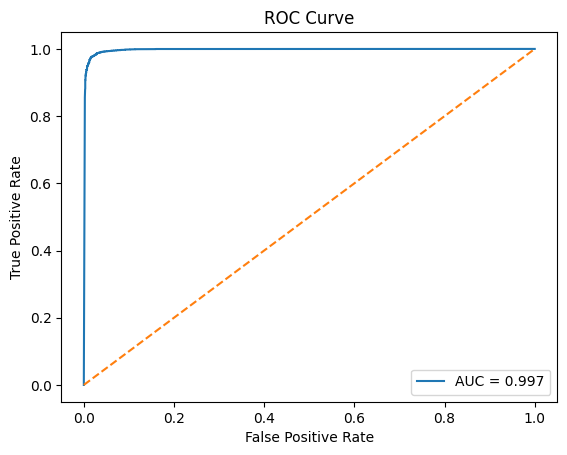

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)

        probs = F.softmax(outputs, dim=1)[:, 1]   # probability of class 1 (fake)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ---------------------------
# CONFUSION MATRIX
# ---------------------------
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

# ---------------------------
# CLASSIFICATION REPORT
# ---------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

# ---------------------------
# ROC CURVE
# ---------------------------
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

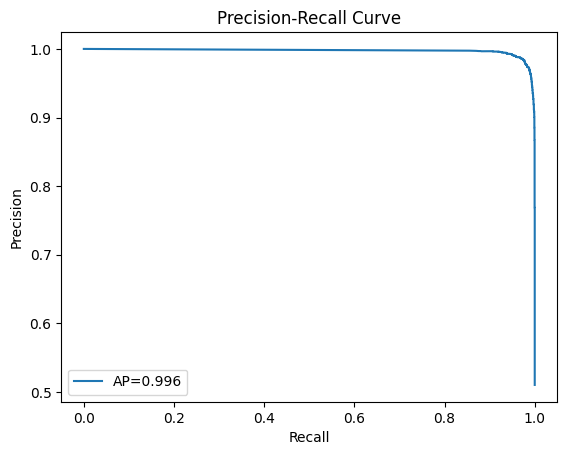

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
avg_prec = average_precision_score(all_labels, all_probs)

plt.plot(recall, precision, label=f"AP={avg_prec:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [ ]:
import numpy as np

all_probs = np.array(all_probs)
print("Mean probability of correct predictions:", all_probs[np.array(all_preds) == np.array(all_labels)].mean())
print("Mean probability of incorrect predictions:", all_probs[np.array(all_preds) != np.array(all_labels)].mean())


Mean probability of correct predictions: 0.5130479
Mean probability of incorrect predictions: 0.59480566


In [ ]:
misclassified = []
for batch in test_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    outputs = model(input_ids, attention_mask)
    _, predicted = torch.max(outputs, 1)

    for i in range(len(labels)):
        if predicted[i] != labels[i]:
            misclassified.append((batch['input_ids'][i], labels[i].item(), predicted[i].item()))


In [ ]:
text = tokenizer.decode(misclassified[0][0])


In [ ]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(all_labels, all_preds)
print("MCC:", mcc)


MCC: 0.9567016902394614
